In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT

In [3]:
dataset = RWF2000Dataset(
    root_dir=DATASET_ROOT,
    split="train",
    num_frames=32,
    image_size=224, 
    augment=True
)

print("Dataset size:", len(dataset))

video, label = dataset[0]

print("Video shape:", video.shape)
print("Label:", label)

Dataset size: 1600
Video shape: torch.Size([32, 3, 224, 224])
Label: tensor(0)


In [4]:
video_num = 987

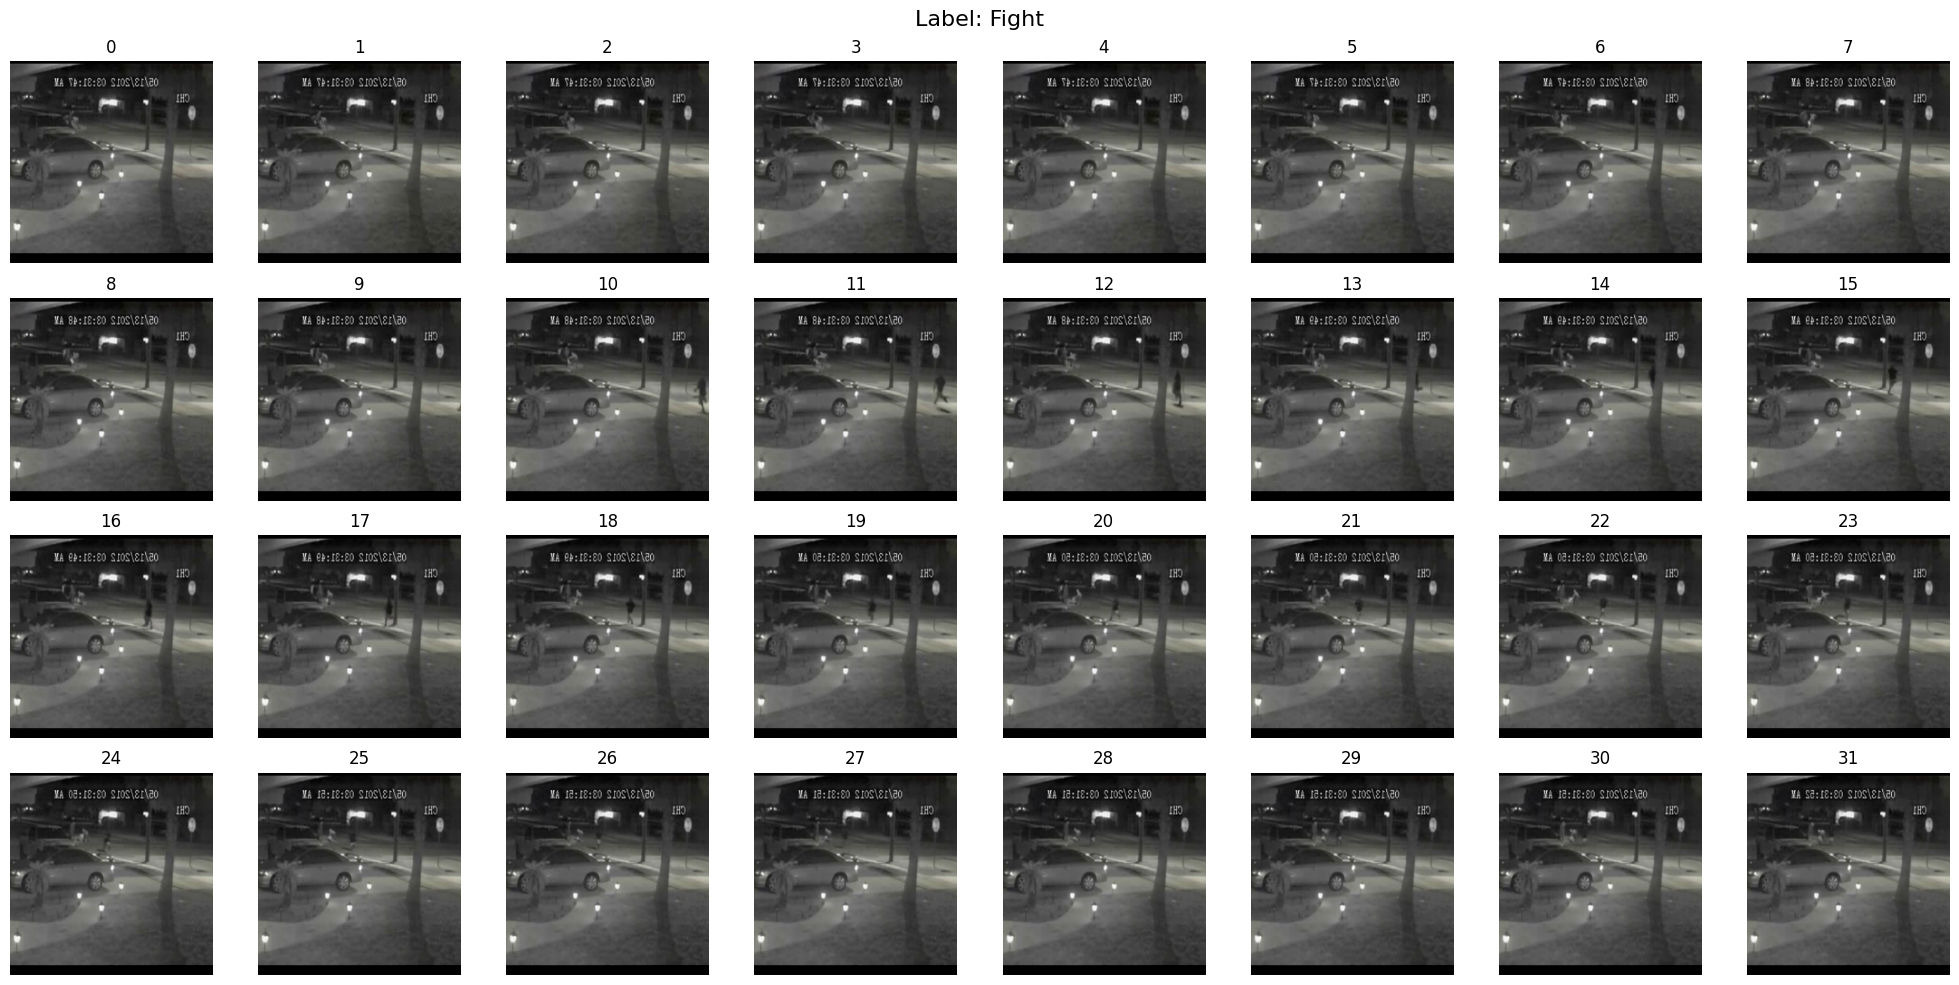

In [7]:
# inspect the uniformly distributed 32 frames

video, label = dataset[video_num]

fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i, ax in enumerate(axes.flatten()):

    frame = video[i]

    # C,H,W -> H,W,C
    frame = frame.permute(1, 2, 0)

    ax.imshow(frame)
    ax.set_title(f"{i}")
    ax.axis("off")

plt.suptitle(
    f"Label: {'Fight' if label.item() == 1 else 'NonFight'}",
    fontsize=16
)

plt.tight_layout()
plt.show()

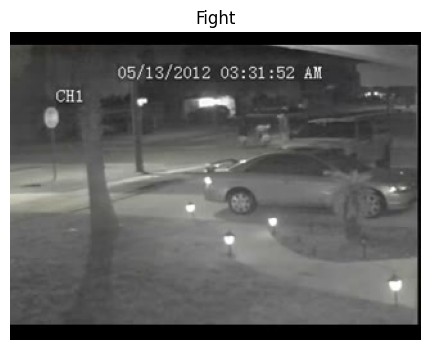

In [8]:
# inspect the original video frames

video_path, label = dataset.samples[video_num]

cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)

while True:
    success, frame = cap.read()
    
    if not success:
        break
    
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    clear_output(wait=True)
    plt.figure(figsize=(6, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title("Fight" if label == 1 else "NonFight")
    plt.show()
    
cap.release()

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

videos, labels = next(iter(train_loader))

print(videos.shape)
print(labels)

torch.Size([4, 32, 3, 224, 224])
tensor([1, 1, 1, 1])
